
# Latency EVT – Multi-Experiment Analysis (seconds)

This notebook reuses `latency_evt_tools_clean.py` through a thin helper (`latency_evt_workflow.py`) to:
- read `block_maxima.csv` (seconds),
- use existing `gev_fit_results.csv` if present,
- estimate throughput,
- extract outliers `> 1.0 s` and fit GPD,
- overlay multiple experiments in **one figure** per chart,
- **save** plots to disk **and** display them inline.

*Generated: 2025-09-22 19:20:45Z*


In [49]:
import os, pandas as pd, numpy as np
from datetime import datetime
from pathlib import Path
import latency_evt_workflow as wf
import sys
sys.path.append('../Analysis-Src/')


# Output directory
OUT_DIR = os.path.abspath(f"./latency_evt_reports_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_DIR


'/Users/soheila/Desktop/RealTime-Streaming-Pipeline/Analysis-Src/latency_evt_reports_20250922_193210'

In [51]:
import sys, importlib, inspect

# Make sure the version I gave you is imported first
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

# Optionally de-prioritize /Analysis-Src so it doesn't shadow
if "/Analysis-Src" in sys.path:
    sys.path.remove("/Analysis-Src")
    sys.path.append("/Analysis-Src")  # keep it, but after /mnt/data

import latency_evt_workflow as wf
importlib.reload(wf)  # ensure fresh load

print("Using module:", wf.__file__)
assert hasattr(wf, "set_label_overrides"), "This wf doesn't have set_label_overrides; path order is wrong."


Using module: /Users/soheila/Desktop/RealTime-Streaming-Pipeline/Analysis-Src/latency_evt_workflow.py


In [53]:
# Experiment directories (edit these paths as needed)
EXPERIMENT_DIRS = [
    "../results/20250922_121352/merge/merge-sts-0_merge-metrics/2025-09-22/", # POLL_TIMEOUT :20 ms
    "../results/20250922_065826/merge/merge-sts-0_merge-metrics/2025-09-22/", # POLL_TIMEOUT :3 ms
    "../results/20250922_021233/merge/merge-sts-0_merge-metrics/2025-09-22/", # POLL_TIMEOUT :5 ms
]

# Add a tiny shim if the function is missing
if not hasattr(wf, "set_label_overrides"):
    def _shim_set_label_overrides(mapping):
        setattr(wf, "LABEL_OVERRIDES", dict(mapping or {}))
    wf.set_label_overrides = _shim_set_label_overrides



# Set label overrides so plots clearly show POLL_TIMEOUT in ms
wf.set_label_overrides({
    "../results/20250922_121352/merge/merge-sts-0_merge-metrics/2025-09-22/": "POLL_TIMEOUT=20ms",
    "../results/20250922_065826/merge/merge-sts-0_merge-metrics/2025-09-22/": "POLL_TIMEOUT=3ms",
    "../results/20250922_021233/merge/merge-sts-0_merge-metrics/2025-09-22/": "POLL_TIMEOUT=5ms",
})

EXPERIMENT_DIRS


['../results/20250922_121352/merge/merge-sts-0_merge-metrics/2025-09-22/',
 '../results/20250922_065826/merge/merge-sts-0_merge-metrics/2025-09-22/',
 '../results/20250922_021233/merge/merge-sts-0_merge-metrics/2025-09-22/']

In [54]:
THRESHOLD_S = 1.0

experiments = []
for d in EXPERIMENT_DIRS:
    try:
        res = wf.analyze_experiment(d, threshold_s=THRESHOLD_S)
        experiments.append(res)
    except Exception as ex:
        print(f"[SKIP] {d}: {ex}")

len(experiments)


3

In [57]:
summary_csv = wf.save_summary(experiments, OUT_DIR)
pd.read_csv(summary_csv)


,label,exp_dir,n_blocks,throughput_rows_per_sec,gev_c,gev_loc,gev_scale,outlier_threshold_s,n_exceedances,gpd_c,gpd_loc,gpd_scale
0,POLL_TIMEOUT=20ms,../results/20250922_121352/merge/merge-sts-0_m...,125448,12544800.0,-1.016461,0.021963,0.002630,1.0,2198,-0.181352,0.0,26.672458
1,POLL_TIMEOUT=3ms,../results/20250922_065826/merge/merge-sts-0_m...,114084,11408400.0,-1.684077,0.006978,0.002228,1.0,2433,-0.137551,0.0,24.613208
2,POLL_TIMEOUT=5ms,../results/20250922_021233/merge/merge-sts-0_m...,8238,823800.0,-1.273055,0.004565,0.000937,1.0,136,-0.610646,0.0,30.304204


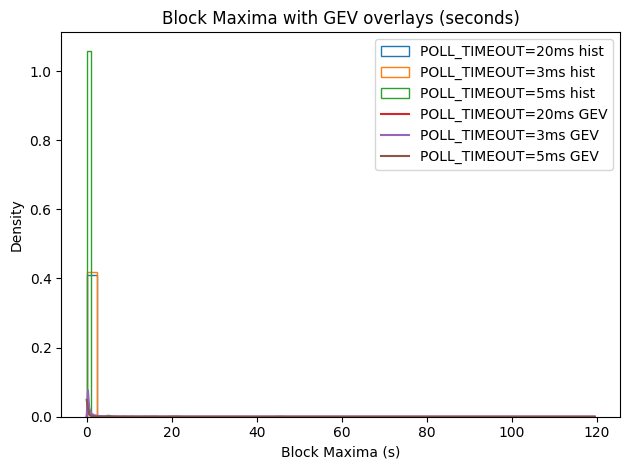

In [63]:
png = os.path.join(OUT_DIR, "hist_gev_overlay.png")
wf.plot_hist_with_gev(experiments, png, show=True)


In [ ]:
png = os.path.join(OUT_DIR, "tail_ccdf_overlay.png")
wf.plot_tail_ccdf(experiments, png, show=True)


png = os.path.join(OUT_DIR, "outliers_ecdf_gpd_overlay.png")
wf.plot_outlier_ecdf_with_gpd(experiments, png, show=True)


png = os.path.join(OUT_DIR, "throughput_bars.png")
wf.plot_throughput_bars(experiments, png, show=True)


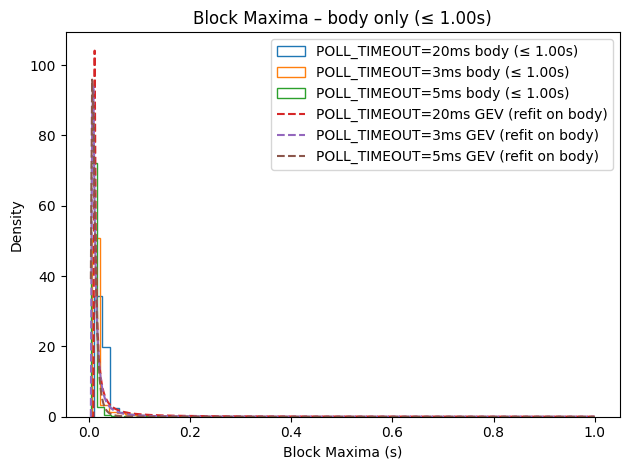

In [71]:
import os, sys
sys.path.append('../Analysis-Src/')
import gev_gpd_diagnostics as diag

# body-only, keep original GEV (for reference)
#png = os.path.join(OUT_DIR, "block_body_no_outliers_ref.png")
#diag.plot_block_maxima_body_no_outliers(experiments, png, threshold_s=1.0, refit=False, show=True)

# body-only and refit GEV on the truncated body (often clearer)
png = os.path.join(OUT_DIR, "block_body_no_outliers_refit.png")
diag.plot_block_maxima_body_no_outliers(experiments, png, threshold_s=1.0, refit=True, show=True)


In [67]:
from scipy import stats

# GEV KS per experiment
gev_tests = []
for e in experiments:
    res = diag.ks_test_gev(e["maxima"], e["gev_params"])
    res["label"] = e["label"]
    res["type"]  = diag.classify_gev_type(e["gev_params"]["c"])
    gev_tests.append(res)

pd.DataFrame(gev_tests).sort_values("label")
ks_truncated_body_gev

,stat,pvalue,n,label,type
0,0.333342,0.0,125448,POLL_TIMEOUT=20ms,Weibull (upper-bounded)
1,0.394632,0.0,114084,POLL_TIMEOUT=3ms,Weibull (upper-bounded)
2,0.537837,0.0,8238,POLL_TIMEOUT=5ms,Weibull (upper-bounded)


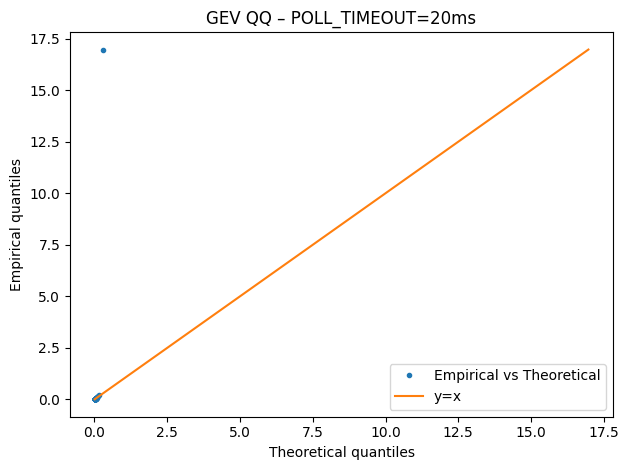

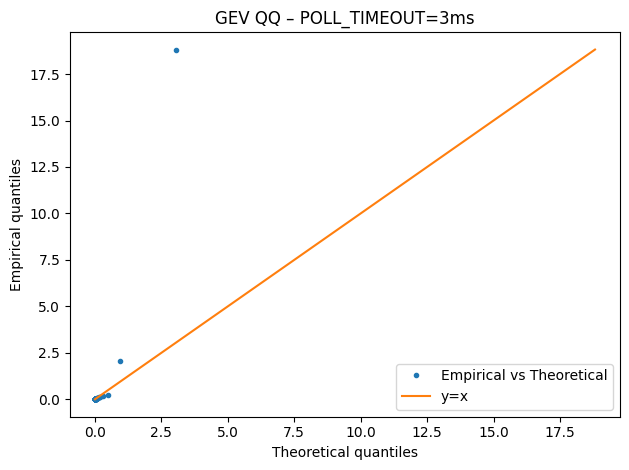

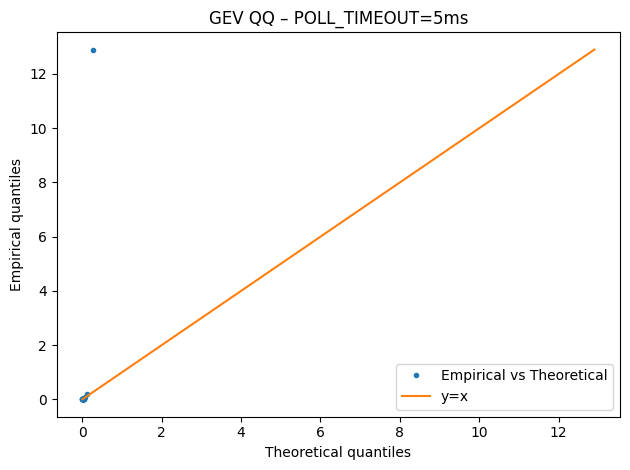

In [68]:
# GEV QQ plots
for e in experiments:
    diag.qqplot(e["maxima"], "gev", e["gev_params"],
                os.path.join(OUT_DIR, f"qq_gev_{e['label'].replace('=','_')}.png"),
                title=f"GEV QQ – {e['label']}", show=True)


In [69]:
# GPD KS per experiment (on exceedances > threshold)
gpd_tests = []
for e in experiments:
    res = diag.ks_test_gpd(e["exceedances"], e["gpd_params"])
    res["label"] = e["label"]
    gpd_tests.append(res)

pd.DataFrame(gpd_tests).sort_values("label")


,stat,pvalue,n,label
0,0.102908,1.016374e-20,2198,POLL_TIMEOUT=20ms
1,0.143768,2.399976e-44,2433,POLL_TIMEOUT=3ms
2,0.177027,3.367187e-04,136,POLL_TIMEOUT=5ms


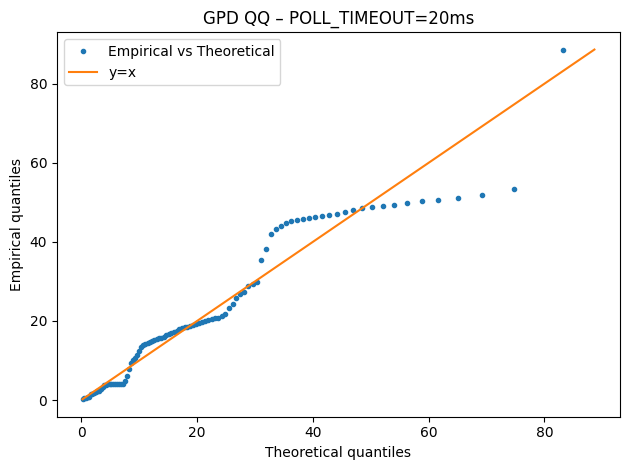

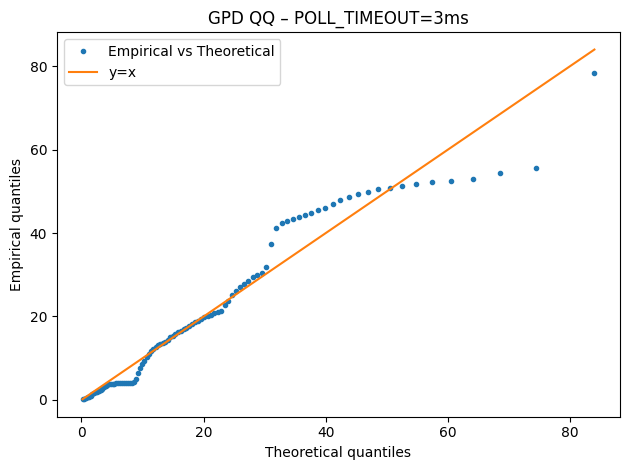

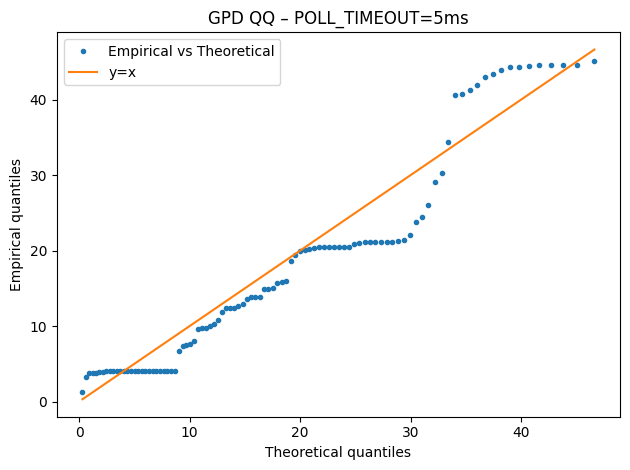

In [70]:
# GPD QQ plots
for e in experiments:
    if e["exceedances"].size > 0 and e["gpd_params"] is not None:
        diag.qqplot(e["exceedances"], "gpd", e["gpd_params"],
                    os.path.join(OUT_DIR, f"qq_gpd_{e['label'].replace('=','_')}.png"),
                    title=f"GPD QQ – {e['label']}", show=True)


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def ks_asymptotic_gev(values, params):
    x = np.asarray(values, float)
    x = x[np.isfinite(x)]
    if x.size < 5 or params is None:
        return dict(stat=np.nan, pvalue=np.nan, n=x.size)
    c, loc, scale = params["c"], params["loc"], params["scale"]
    cdf = lambda t: stats.genextreme.cdf(t, c=c, loc=loc, scale=scale)
    stat, p = stats.kstest(x, cdf)
    return dict(stat=float(stat), pvalue=float(p), n=int(x.size))

def ks_bootstrap_gev(values, params, B=400, random_state=0):
    """Parametric bootstrap KS for GEV with refit on each bootstrap sample."""
    rng = np.random.default_rng(random_state)
    x = np.asarray(values, float)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 5 or params is None:
        return dict(p_boot=np.nan, B=0)

    # observed D wrt fitted params
    c0, loc0, scale0 = params["c"], params["loc"], params["scale"]
    obs_cdf = lambda t: stats.genextreme.cdf(t, c=c0, loc=loc0, scale=scale0)
    D_obs, _ = stats.kstest(x, obs_cdf)

    # bootstrap
    Db = []
    for _ in range(B):
        xb = stats.genextreme.rvs(c=c0, loc=loc0, scale=scale0, size=n, random_state=rng)
        # refit on bootstrap sample
        cb, locb, scaleb = stats.genextreme.fit(xb)
        scaleb = max(scaleb, 1e-9)
        cdfb = lambda t: stats.genextreme.cdf(t, c=cb, loc=locb, scale=scaleb)
        d, _ = stats.kstest(xb, cdfb)
        Db.append(d)

    Db = np.asarray(Db)
    p_boot = float(np.mean(Db >= D_obs))
    return dict(p_boot=p_boot, D_obs=float(D_obs), D_boot_mean=float(Db.mean()), B=int(B))

def ks_asymptotic_gpd(exceedances, params):
    exc = np.asarray(exceedances, float)
    exc = exc[np.isfinite(exc)]
    if exc.size < 10 or params is None:
        return dict(stat=np.nan, pvalue=np.nan, n=exc.size)
    cdf = lambda t: stats.genpareto.cdf(t, c=params["c"], loc=params["loc"], scale=params["scale"])
    stat, p = stats.kstest(exc, cdf)
    return dict(stat=float(stat), pvalue=float(p), n=int(exc.size))

def ks_bootstrap_gpd(exceedances, params, B=400, random_state=0):
    rng = np.random.default_rng(random_state)
    exc = np.asarray(exceedances, float)
    exc = exc[np.isfinite(exc)]
    n = exc.size
    if n < 10 or params is None:
        return dict(p_boot=np.nan, B=0)

    c0, loc0, scale0 = params["c"], params["loc"], params["scale"]
    obs_cdf = lambda t: stats.genpareto.cdf(t, c=c0, loc=loc0, scale=scale0)
    D_obs, _ = stats.kstest(exc, obs_cdf)

    Db = []
    for _ in range(B):
        xb = stats.genpareto.rvs(c=c0, loc=loc0, scale=scale0, size=n, random_state=rng)
        # refit on bootstrap sample
        cb, locb, scaleb = stats.genpareto.fit(xb, floc=0.0)
        scaleb = max(scaleb, 1e-12)
        cdfb = lambda t: stats.genpareto.cdf(t, c=cb, loc=locb, scale=scaleb)
        d, _ = stats.kstest(xb, cdfb)
        Db.append(d)

    Db = np.asarray(Db)
    p_boot = float(np.mean(Db >= D_obs))
    return dict(p_boot=p_boot, D_obs=float(D_obs), D_boot_mean=float(Db.mean()), B=int(B))

# ---- run for your experiments ----
rows = []
for e in experiments:
    gev_asym = ks_asymptotic_gev(e["maxima"], e["gev_params"])
    gev_boot = ks_bootstrap_gev(e["maxima"], e["gev_params"], B=400, random_state=42)

    gpd_asym = ks_asymptotic_gpd(e["exceedances"], e["gpd_params"])
    gpd_boot = ks_bootstrap_gpd(e["exceedances"], e["gpd_params"], B=400, random_state=42)

    rows.append({
        "label": e["label"],
        "n_maxima": gev_asym["n"],
        "KS_D_GEV": gev_asym["stat"],
        "KS_p_asym_GEV": gev_asym["pvalue"],
        "KS_p_boot_GEV": gev_boot["p_boot"],
        "KS_D_boot_mean_GEV": gev_boot["D_boot_mean"],
        "n_exceed": gpd_asym["n"],
        "KS_D_GPD": gpd_asym["stat"],
        "KS_p_asym_GPD": gpd_asym["pvalue"],
        "KS_p_boot_GPD": gpd_boot["p_boot"],
        "KS_D_boot_mean_GPD": gpd_boot["D_boot_mean"],
    })

pd.DataFrame(rows)


In [73]:
import numpy as np
import pandas as pd
from scipy import stats

def ks_truncated_body_gev(values, params, u, jitter=0.0, random_state=0):
    """
    KS test for the *body only* (X ≤ u) against a GEV *truncated at u*.
    - values: 1D array-like of block maxima (seconds)
    - params: dict with keys {'c','loc','scale'} fitted on full data (or your choice)
    - u: truncation threshold in seconds (e.g., 1.0)
    - jitter: optional tiny Gaussian jitter to break ties (default 0)
    - returns: dict(stat, pvalue, n, Fu)
    """
    x = np.asarray(values, float)
    x = x[np.isfinite(x) & (x <= u)]
    n = x.size
    if n < 5 or params is None:
        return dict(stat=np.nan, pvalue=np.nan, n=n, Fu=np.nan)

    # Optional tiny jitter can help when there are many ties in seconds
    if jitter and n > 0:
        rng = np.random.default_rng(random_state)
        x = x + rng.normal(0.0, float(jitter), size=n)

    c, loc, scale = float(params["c"]), float(params["loc"]), float(params["scale"])
    # CDF at the truncation point u
    Fu = stats.genextreme.cdf(u, c=c, loc=loc, scale=scale)

    # Truncated CDF: F_tr(x) = F(x)/F(u), for x <= u
    def cdf_truncated(t):
        Ft = stats.genextreme.cdf(t, c=c, loc=loc, scale=scale)
        # Clamp to [0,1] for numeric safety
        return np.clip(Ft / Fu, 0.0, 1.0)

    stat, p = stats.kstest(x, cdf_truncated)
    return dict(stat=float(stat), pvalue=float(p), n=int(n), Fu=float(Fu))


In [75]:
# Choose body cutoff (seconds)
u = 1.0

rows = []
for e in experiments:
    res = ks_truncated_body_gev(e["maxima"], e["gev_params"], u=u, jitter=1e-6)
    rows.append({
        "label": e["label"],
        "n_body": res["n"],
        "KS_D_body_truncGEV": res["stat"],
        "KS_p_body_truncGEV": res["pvalue"],
        "F(u) under GEV": res["Fu"],  # mass up to u per your full-fit params
    })

pd.DataFrame(rows).sort_values("label")


,label,n_body,KS_D_body_truncGEV,KS_p_body_truncGEV,F(u) under GEV
0,POLL_TIMEOUT=20ms,123250,0.339286,0.0,0.997099
1,POLL_TIMEOUT=3ms,111651,0.402052,0.0,0.980592
2,POLL_TIMEOUT=5ms,8102,0.536000,0.0,0.996537


In [76]:
import numpy as np
from scipy import stats

def sample_truncated_gev(n, c, loc, scale, u, rng):
    """
    Draw n samples from GEV(c,loc,scale) *conditioned on X <= u* via rejection sampling.
    Efficient because F(u) is ~1 in your case.
    """
    out = []
    Fu = stats.genextreme.cdf(u, c=c, loc=loc, scale=scale)
    # expected draws needed ~ n / F(u)
    need = n
    while len(out) < n:
        k = int(np.ceil(need / max(Fu, 1e-12)))  # propose a bit more than needed
        x = stats.genextreme.rvs(c=c, loc=loc, scale=scale, size=k, random_state=rng)
        x = x[x <= u]
        out.extend(x.tolist())
        need = n - len(out)
    return np.array(out[:n], dtype=float)

def ks_truncated_body_gev(values, params, u, jitter=0.0, random_state=0):
    """Same as before, KS vs truncated GEV CDF."""
    x = np.asarray(values, float)
    x = x[np.isfinite(x) & (x <= u)]
    n = x.size
    if n < 5 or params is None:
        return dict(stat=np.nan, pvalue=np.nan, n=n, Fu=np.nan, cdf=None)

    if jitter and n > 0:
        rng = np.random.default_rng(random_state)
        x = x + rng.normal(0.0, float(jitter), size=n)

    c, loc, scale = float(params["c"]), float(params["loc"]), float(params["scale"])
    Fu = stats.genextreme.cdf(u, c=c, loc=loc, scale=scale)

    def cdf_truncated(t):
        Ft = stats.genextreme.cdf(t, c=c, loc=loc, scale=scale)
        return np.clip(Ft / Fu, 0.0, 1.0)

    stat, p = stats.kstest(x, cdf_truncated)
    return dict(stat=float(stat), pvalue=float(p), n=int(n), Fu=float(Fu), cdf=cdf_truncated)

def ks_truncated_body_gev_boot(values, params, u, B=200, jitter=0.0, random_state=42):
    """
    Parametric bootstrap p-value for truncated-gev KS: simulate from the truncated model,
    compute KS each time, and compare to observed.
    """
    rng = np.random.default_rng(random_state)
    res = ks_truncated_body_gev(values, params, u, jitter=jitter, random_state=random_state)
    if not np.isfinite(res["stat"]) or res["n"] < 5:
        return {**res, "p_boot": np.nan, "B": 0, "D_boot_mean": np.nan}

    c, loc, scale = float(params["c"]), float(params["loc"]), float(params["scale"])
    n = res["n"]
    D_obs = res["stat"]

    Db = []
    for _ in range(B):
        xb = sample_truncated_gev(n, c, loc, scale, u, rng)
        if jitter and n > 0:
            xb = xb + rng.normal(0.0, float(jitter), size=n)
        # KS vs the same truncated CDF (params fixed)
        Fu = stats.genextreme.cdf(u, c=c, loc=loc, scale=scale)
        def cdf_truncated_b(t):
            Ft = stats.genextreme.cdf(t, c=c, loc=loc, scale=scale)
            return np.clip(Ft / Fu, 0.0, 1.0)
        d, _ = stats.kstest(xb, cdf_truncated_b)
        Db.append(d)

    Db = np.asarray(Db, float)
    p_boot = float(np.mean(Db >= D_obs))
    return {"stat": D_obs, "n": n, "p_boot": p_boot, "B": int(B), "D_boot_mean": float(Db.mean())}


In [77]:
u = 1.0
rows = []
for e in experiments:
    boot = ks_truncated_body_gev_boot(e["maxima"], e["gev_params"], u, B=400, jitter=1e-6, random_state=7)
    rows.append({
        "label": e["label"],
        "n_body": boot["n"],
        "KS_D_body_truncGEV": boot["stat"],
        "KS_p_boot_body_truncGEV": boot["p_boot"],
        "D_boot_mean": boot["D_boot_mean"],
        "B": boot["B"],
    })
pd.DataFrame(rows).sort_values("label")


,label,n_body,KS_D_body_truncGEV,KS_p_boot_body_truncGEV,D_boot_mean,B
0,POLL_TIMEOUT=20ms,123250,0.339287,0.0,0.002462,400
1,POLL_TIMEOUT=3ms,111651,0.402056,0.0,0.002572,400
2,POLL_TIMEOUT=5ms,8102,0.535990,0.0,0.009543,400


In [78]:
def ks_refit_body_gev(values, u, jitter=0.0, random_state=0, B=200):
    x = np.asarray(values, float)
    x = x[np.isfinite(x) & (x <= u)]
    n = x.size
    if n < 5:
        return dict(n=n, c=np.nan, loc=np.nan, scale=np.nan,
                    D_obs=np.nan, p_asym=np.nan, p_boot=np.nan, D_boot_mean=np.nan, B=0)

    if jitter and n > 0:
        rng = np.random.default_rng(random_state)
        x = x + rng.normal(0.0, float(jitter), size=n)

    # Fit GEV on the truncated body data
    c, loc, scale = stats.genextreme.fit(x)
    scale = max(scale, 1e-9)
    cdf = lambda t: stats.genextreme.cdf(t, c=c, loc=loc, scale=scale)
    D_obs, p_asym = stats.kstest(x, cdf)

    # Bootstrap p-value with refit on each bootstrap sample
    rng = np.random.default_rng(random_state)
    Db = []
    for _ in range(B):
        xb = stats.genextreme.rvs(c=c, loc=loc, scale=scale, size=n, random_state=rng)
        if jitter and n > 0:
            xb = xb + rng.normal(0.0, float(jitter), size=n)
        cb, locb, scaleb = stats.genextreme.fit(xb)
        scaleb = max(scaleb, 1e-9)
        cdfb = lambda t: stats.genextreme.cdf(t, c=cb, loc=locb, scale=scaleb)
        d, _ = stats.kstest(xb, cdfb)
        Db.append(d)

    Db = np.asarray(Db, float)
    p_boot = float(np.mean(Db >= D_obs))
    return dict(n=n, c=float(c), loc=float(loc), scale=float(scale),
                D_obs=float(D_obs), p_asym=float(p_asym),
                p_boot=p_boot, D_boot_mean=float(Db.mean()), B=int(B))


In [79]:
u = 1.0
rows = []
for e in experiments:
    out = ks_refit_body_gev(e["maxima"], u, jitter=1e-6, random_state=11, B=400)
    out["label"] = e["label"]
    rows.append(out)
pd.DataFrame(rows).sort_values("label")


KeyboardInterrupt: 